# AmsterdamUMCdb Measurement table Exploration

## Objectives
- Map the [Zappalà et al. (2025)](https://www.sciencedirect.com/science/article/pii/S0883944125000929) predictor variables(vitals, ventilator settings, blood gases, labs) to concept_ids.
- Validate each concept by visit count and value completeness(% of rows with an actual value)
- Check unit consistency and plausible value ranges per feature
- Identify censored values(operator < / > ) the need handling


### Imports

In [1]:
import pandas as pd
import numpy as np
#!pip install google-cloud-bigquery --quiet
from google.cloud import bigquery
import matplotlib.pyplot as plt

Initial BigQuery Setup by Ayushi Kashyap - Adapted for this notebook.

### Retrieving Google Project Id

In [2]:
client = bigquery.Client()

print("Connected to BigQuery")

Connected to BigQuery


In [3]:
# sets *your* project id
PROJECT_ID = "capstoneweaningprediction" #@param {type:"string"}

# Sets the default BigQuery dataset for accessing AmsterdamUMCdb

If you have received instructions to use a specific BigQuery instance, change the default settings here. Otherwise use these default values.

In [4]:
# sets default dataset for AmsterdamUMCdb
DATASET_PROJECT_ID = 'amsterdamumcdb' #@param {type:"string"}
DATASET_ID = 'version1_5_0' #@param {type:"string"}
LOCATION = 'eu' #@param {type:"string"}

# Provide your credentials to access the AmsterdamUMCdb dataset on Google BigQuery
Authenticate your credentials with Google Cloud Platform and set your default Google Cloud Project ID as an environment variable for running query jobs.

1. Run the cell. The `Allow this notebook to access your Google credentials?` prompt appears. Select `Allow`.
2. In the `Sign in - Google Accounts` dialog, use the account you registered during the AmsterdamUMCdb application process and select `Allow` again.

In [5]:
import os
from google.colab import auth

# all libraries check this environment variable, so set it:
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

auth.authenticate_user()
print('Authenticated')

Authenticated


# Enable data table display

Colab includes the `google.colab.data_table` package that can be used to display Pandas dataframes as an interactive data table (default limits: `max_rows = 20000`, `max_columns = 20`). This is especially useful when exploring the  tables or dictionary from AmsterdamUMCdb. It can be enabled with:

In [6]:
%load_ext google.colab.data_table
from google.colab.data_table import DataTable

# change default limits:
DataTable.max_columns = 50
DataTable.max_rows = 80000


## Set the default query job configuration for magics

In [7]:
#!pip install bigquery_magics --quiet
%load_ext bigquery_magics
from bigquery_magics import bigquery_magics
from google.cloud import bigquery

# sets the default query job configuration
def_config = bigquery.job.QueryJobConfig(default_dataset=DATASET_PROJECT_ID + "." + DATASET_ID)
bigquery_magics.context.default_query_job_config = def_config

## Query the `person` table and copy the data to the `persons` Pandas dataframe:

The `person` table contains a record for each patient in AmsterdamUMCdb.

Since this is a relatively small table, it is acceptable to use `SELECT *`.

**Note**: Should an error occur while running the query, please see
the AmsterdamUMCdb BigQuery [Frequently Asked Questions](https://github.com/AmsterdamUMC/AmsterdamUMCdb/wiki/bigquery#faq).

In [8]:
%%bigquery person
SELECT * FROM `amsterdamumcdb.version1_5_0.person`;

Query is running:   0%|          |

Downloading:   0%|          |


## Set the default query job configuration for google-cloud-bigquery client

In [9]:
from google.cloud import bigquery

# BigQuery requires a separate config to prevent the 'BadRequest: 400 Cannot explicitly modify anonymous table' error message
job_config = bigquery.job.QueryJobConfig()

# sets default client settings by re-using the previously defined config
client = bigquery.Client(project=PROJECT_ID, location=LOCATION, default_query_job_config=def_config)

### List Tables

In [10]:
query = f"""
SELECT table_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

tables = client.query(query).to_dataframe()

tables

,table_name
0,care_site
1,cdm_source
2,cohort
3,cohort_definition
4,concept
5,concept_ancestor
6,concept_class
7,concept_relationship
8,concept_synonym
9,condition_era


Step 1 — Explore Measurement Table

In [11]:
query = f"""
SELECT *
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id IS NOT NULL
LIMIT 100000
"""

measurement_df = client.query(query).to_dataframe()

measurement_df.head()

,measurement_id,person_id,measurement_concept_id,measurement_date,measurement_datetime,measurement_time,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,...,provider_id,visit_occurrence_id,visit_detail_id,measurement_source_value,measurement_source_concept_id,unit_source_value,unit_source_concept_id,value_source_value,measurement_event_id,meas_event_field_concept_id
0,25659859,8166,46237002,2013-01-03,2013-01-03 02:03:00+00:00,02:03:00,32817,<NA>,None,36308950,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,3. Severe Disability,<NA>,<NA>
1,25659535,8166,46237002,2013-01-01,2013-01-01 04:03:00+00:00,04:03:00,32817,<NA>,None,36309649,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>
2,25659686,8166,46237002,2013-01-02,2013-01-02 02:03:00+00:00,02:03:00,32817,<NA>,None,36309649,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>
3,25659973,8166,46237002,2013-01-04,2013-01-04 02:03:00+00:00,02:03:00,32817,<NA>,None,36310710,...,40,9475,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,5. Good Recovery,<NA>,<NA>
4,38399563,16815,46237002,2012-12-31,2012-12-31 13:17:00+00:00,13:17:00,32817,<NA>,None,36309649,...,40,19488,<NA>,GOS (Glasgow Outcome Score),<NA>,None,<NA>,2. Persistent vegetative state,<NA>,<NA>


In [12]:
measurement_df['measurement_concept_id'].value_counts()

,count
measurement_concept_id,
40760770,96111
46236952,3769
46237002,120


### Inspect Columns

In [13]:
measurement_df.columns

Index(['measurement_id', 'person_id', 'measurement_concept_id',
       'measurement_date', 'measurement_datetime', 'measurement_time',
       'measurement_type_concept_id', 'operator_concept_id', 'value_as_number',
       'value_as_concept_id', 'unit_concept_id', 'range_low', 'range_high',
       'provider_id', 'visit_occurrence_id', 'visit_detail_id',
       'measurement_source_value', 'measurement_source_concept_id',
       'unit_source_value', 'unit_source_concept_id', 'value_source_value',
       'measurement_event_id', 'meas_event_field_concept_id'],
      dtype='object')

### Count total measurements

In [14]:
measurement_df.shape

(100000, 23)

### Identify Most Common Measurements

In [15]:
query = f"""
SELECT
    c.concept_name,
    COUNT(*) as frequency
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.provider_id IS NOT NULL
GROUP BY c.concept_name
ORDER BY frequency DESC
LIMIT 50
"""

common_measurements = client.query(query).to_dataframe()

common_measurements

,concept_name,frequency
0,Urine output,3319256
1,Carbon dioxide production (VCO2) in Respirator...,3084460
2,Tidal volume inspired spontaneous+mechanical M...,2558732
3,Expired minute Volume during Mechanical ventil...,2558460
4,Tidal volume expired spontaneous+mechanical Re...,2558248
5,Inspired minute Volume during Mechanical venti...,2557314
6,Heart rate.beat-to-beat by EKG,2218626
7,Rise time setting Ventilator,2200447
8,Invasive Systolic blood pressure,2115980
9,Invasive Diastolic blood pressure,2115548


Ventilator parameters and continuous vitals dominate the top frequencies, reflecting the high-frequency logging of mechanically ventilated ICU patients.

### Search Respiratory Measurements

In [16]:
query = f"""
SELECT
    DISTINCT concept_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%resp%'
"""

resp_measurements = client.query(query).to_dataframe()

resp_measurements

,concept_name
0,Absence of postural response; would fall if no...
1,Medical-Respiratory Distress-Bronchiolitis
2,No response; head hangs laterally or in flexion.
3,"No response, head hangs."
4,UPPER RESPIRATORY STAPH STEP COMBINATION - sta...
...,...
8518,"Poisoning by, adverse effect of and underdosin..."
8519,Other foreign object in other parts of respira...
8520,"Coma scale, best motor response"
8521,Measurement of Severe acute respiratory syndro...


### Measurement Frequency Per Patient

In [17]:
query = f"""
SELECT
    person_id,
    COUNT(*) as measurement_count
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id is not null
GROUP BY person_id
ORDER BY measurement_count DESC
LIMIT 100000
"""

measurement_per_person = client.query(query).to_dataframe()

measurement_per_person

,person_id,measurement_count
0,9989,238314
1,19290,176589
2,7010,153074
3,15798,145608
4,5249,145004
...,...,...
20104,7042,13
20105,8773,10
20106,16086,10
20107,9123,7


There's a density gap even within the top 20 — person 9989 has over 238k measurements while person 4353 sits at 81k, nearly a 3x difference, pointing to significant variation in ICU stay length or monitoring intensity.

### Explore Missingness

In [18]:
measurement_df.isnull().sum()

,0
measurement_id,0
person_id,0
measurement_concept_id,0
measurement_date,0
measurement_datetime,0
measurement_time,0
measurement_type_concept_id,0
operator_concept_id,98436
value_as_number,120
value_as_concept_id,99880


The missingness here is structural rather than random — fields like `value_as_number`, `unit_concept_id`, and `range_low/high` are consistently absent together, suggesting certain measurement types simply don't carry numeric values or units, which will push the decision toward exclusion or concept-level stratification before any filling strategy makes sense.

### Distribution of Physiological Variables

#### Heart-Rate Distribution

In [19]:
query = f"""
SELECT
    value_as_number
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.measurement_concept_id = 21490872
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
AND value_as_number > 0
LIMIT 100000
"""

heart_dist = client.query(query).to_dataframe()
heart_dist

,value_as_number
0,17.00000000000000000000000000000000000000
1,17.00000000000000000000000000000000000000
2,18.00000000000000000000000000000000000000
3,19.00000000000000000000000000000000000000
4,20.00000000000000000000000000000000000000
...,...
99995,68.00000000000000000000000000000000000000
99996,68.00000000000000000000000000000000000000
99997,68.00000000000000000000000000000000000000
99998,68.00000000000000000000000000000000000000


(array([7.0000e+00, 1.1000e+01, 1.1000e+01, 6.5000e+01, 2.0010e+03,
        5.1070e+03, 8.0010e+03, 1.6470e+04, 2.5950e+04, 4.2377e+04]),
 array([17. , 22.1, 27.2, 32.3, 37.4, 42.5, 47.6, 52.7, 57.8, 62.9, 68. ]),
 <BarContainer object of 10 artists>)

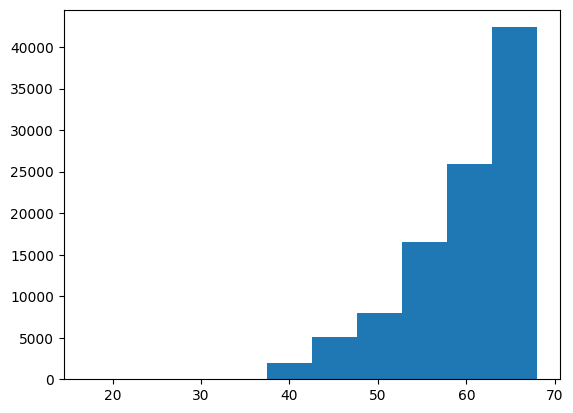

In [20]:
plt.hist(heart_dist['value_as_number'])

The distribution is left skewed, most of the patients have heart rate between 70-80 which is normal. Few patients have low heart rate less than 40.

#### Respiratoy-Rate Distribution

In [21]:
query = f"""
SELECT
    value_as_number
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.measurement_concept_id = 3024171
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
AND value_as_number > 0
LIMIT 100000
"""

rr_dist = client.query(query).to_dataframe()
rr_dist

,value_as_number
0,32.00000000000000000000000000000000000000
1,27.00000000000000000000000000000000000000
2,28.00000000000000000000000000000000000000
3,26.00000000000000000000000000000000000000
4,30.00000000000000000000000000000000000000
...,...
99995,7.00000000000000000000000000000000000000
99996,7.00000000000000000000000000000000000000
99997,7.00000000000000000000000000000000000000
99998,7.00000000000000000000000000000000000000


(array([8.7476e+04, 1.2432e+04, 8.4000e+01, 7.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([  1. ,  17.8,  34.6,  51.4,  68.2,  85. , 101.8, 118.6, 135.4,
        152.2, 169. ]),
 <BarContainer object of 10 artists>)

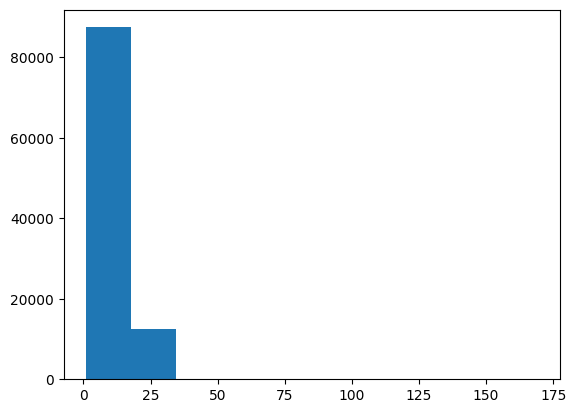

In [22]:
plt.hist(rr_dist['value_as_number'])

Respiratory rate distribution is right-skewed, with most observations concentrated at higher rates (10–30 breaths/min) and and a small number of higher respiratory rates extending up to around 50 breaths/min.

In [23]:
query = f"""
SELECT concept_id, concept_name, vocabulary_id, standard_concept
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%respiratory rate%'
AND standard_concept = 'S'
"""

concepts = client.query(query).to_dataframe()
concepts

,concept_id,concept_name,vocabulary_id,standard_concept
0,3037535,Respiratory rate at First encounter,LOINC,S
1,3007823,Respiratory rate 8 hour maximum,LOINC,S
2,3011032,Respiratory rate --post cardioversion,LOINC,S
3,3019610,Respiratory rate --post inhalation therapy,LOINC,S
4,3026425,Respiratory rate 12 hour,LOINC,S
5,3010057,Respiratory rate --pre inhalation therapy,LOINC,S
6,3012944,Respiratory rate 24 hour,LOINC,S
7,3013114,Respiratory rate 12 hour minimum,LOINC,S
8,3025744,Respiratory rate 8 hour minimum,LOINC,S
9,3012146,Respiratory rate 10 hour,LOINC,S


#### SpO2 Distribution

In [24]:
# First check the concept ID
query = f"""
SELECT concept_id, concept_name, vocabulary_id, standard_concept
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.concept`
WHERE LOWER(concept_name) LIKE '%oxygen saturation%'
AND standard_concept = 'S'
"""
concepts = client.query(query).to_dataframe()
concepts

,concept_id,concept_name,vocabulary_id,standard_concept
0,43533819,Infant activity during preductal oxygen satura...,LOINC,S
1,43533824,Oxygen saturation sensor wrap type,LOINC,S
2,43533826,Oxygen saturation sensor type,LOINC,S
3,43533823,Oxygen saturation sensor wrap size,LOINC,S
4,43533827,Oxygen saturation sensor name,LOINC,S
...,...,...,...,...
130,40762503,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S
131,40762507,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S
132,40762497,Oxygen saturation (8 hour minimum) in Arterial...,LOINC,S
133,40762500,Oxygen saturation in Arterial blood by Pulse o...,LOINC,S


In [25]:
query = f"""
SELECT
    value_as_number,
    unit_source_value,
    unit_concept_id
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
WHERE m.measurement_concept_id = 40762499
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
LIMIT 100000
"""

spo2_dist = client.query(query).to_dataframe()
spo2_dist

,value_as_number,unit_source_value,unit_concept_id
0,0E-38,None,8554
1,35.00000000000000000000000000000000000000,None,8554
2,61.00000000000000000000000000000000000000,None,8554
3,68.00000000000000000000000000000000000000,None,8554
4,75.00000000000000000000000000000000000000,None,8554
...,...,...,...
99995,95.00000000000000000000000000000000000000,None,8554
99996,95.00000000000000000000000000000000000000,None,8554
99997,95.00000000000000000000000000000000000000,None,8554
99998,95.00000000000000000000000000000000000000,None,8554


(array([2.8000e+01, 1.8000e+01, 2.3000e+01, 4.1000e+01, 5.1000e+01,
        1.2200e+02, 2.2700e+02, 8.4000e+02, 7.3870e+03, 9.1263e+04]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

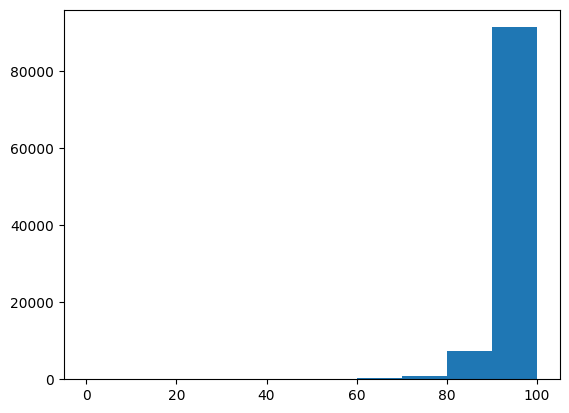

In [26]:
plt.hist(spo2_dist['value_as_number'])

The distribution is left-skewed, with most of the observations concentrated at higher oxygen saturation level.

### Top 20 concepts of patient with most measurements

AI-assisted (Claude, Anthropic — Claude Opus 4.8): time-series density / irregular-sampling exploration drafted with AI.

In [ ]:
# Step 1: Pick a patient with many measurements
query = f"""
SELECT
    person_id,
    COUNT(*) as measurement_count
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement`
WHERE provider_id is not null or provider_id is null
GROUP BY person_id
ORDER BY measurement_count DESC
LIMIT 1
"""
top_patient = client.query(query).to_dataframe()
patient_id = top_patient['person_id'].values[0]
print(f"Selected patient: {patient_id}")

# Step 2: Pull all measurements for that patient
query = f"""
SELECT
    measurement_datetime,
    value_as_number,
    c.concept_name
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id = c.concept_id
WHERE m.person_id = {patient_id}
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
AND value_as_number IS NOT NULL
ORDER BY measurement_datetime
"""
patient_ts = client.query(query).to_dataframe()

# Step 3: Visualize time-series density
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

patient_ts['measurement_datetime'] = pd.to_datetime(patient_ts['measurement_datetime'])

# Get top 20 most frequent concepts for readability
top_concepts = patient_ts['concept_name'].value_counts().head(20).index
filtered_ts = patient_ts[patient_ts['concept_name'].isin(top_concepts)]

# Shorten long concept names
filtered_ts = filtered_ts.copy()
filtered_ts['concept_short'] = filtered_ts['concept_name'].str[:40]

plt.figure(figsize=(18, 10))
concepts = filtered_ts['concept_short'].unique()
concept_map = {c: i for i, c in enumerate(concepts)}

plt.scatter(
    filtered_ts['measurement_datetime'],
    filtered_ts['concept_short'].map(concept_map),
    s=1, alpha=0.3, color='steelblue'
)

plt.yticks(range(len(concepts)), concepts, fontsize=9)
plt.xlabel('Time', fontsize=12)
plt.title(f'Time-Series Density for Patient {patient_id} (Top 20 Concepts)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Step 4: Check gaps between consecutive measurements
patient_ts_sorted = patient_ts.sort_values('measurement_datetime')
patient_ts_sorted['gap_minutes'] = patient_ts_sorted['measurement_datetime'].diff().dt.total_seconds() / 60
print("Gap statistics (minutes):")
print(patient_ts_sorted['gap_minutes'].describe())
print(f"\nLargest gaps (hours):")
print((patient_ts_sorted['gap_minutes'].nlargest(5) / 60).round(1))

Selected patient: 16921


The patient was monitored very frequently, with most measurements recorded continuously over time, but there was some period where no data was collected.

### Value Completeness Per Feature

AI-assisted (Claude, Anthropic — Claude Opus 4.8): feature value-completeness query drafted with AI.

In [ ]:
FEATURE_IDS = "3027018,21490852,3024171,40762499,21490855,3016166,3047181,4105091,21490872"
query = f"""
SELECT m.measurement_concept_id, c.concept_name,
       COUNT(*) AS n_rows,
       COUNT(m.value_as_number) AS n_value,
       ROUND(100*COUNT(m.value_as_number)/COUNT(*),1) AS pct_value,
       COUNT(DISTINCT m.visit_occurrence_id) AS n_visits
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c ON m.measurement_concept_id=c.concept_id
WHERE m.measurement_concept_id IN ({FEATURE_IDS})
AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
GROUP BY 1,2 ORDER BY n_visits DESC
"""
completness_df = client.query(query).to_dataframe()
completness_df

All key physiological and ventilator variables show excellent value completeness except Ramsay sedation scale.

### Unit consistency per feature

In [ ]:
query = f"""
SELECT m.measurement_concept_id,c.concept_name,m.unit_source_value,
       COUNT(*) AS n
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id=c.concept_id
WHERE measurement_concept_id IN ({FEATURE_IDS})
AND (provider_id IS NOT NULL OR provider_id IS NULL)
GROUP BY 1,2,3 ORDER BY 1, n DESC
"""
client.query(query).to_dataframe()

### Operator Check

In [ ]:
query = f"""
SELECT m.measurement_concept_id, c.concept_name,
       COUNTIF(m.operator_concept_id IS NOT NULL AND m.operator_concept_id<>4172703) AS n_censored,
       COUNT(*) AS n_rows
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
ON m.measurement_concept_id=c.concept_id
WHERE measurement_concept_id IN ({FEATURE_IDS})
AND (provider_id IS NOT NULL OR provider_id IS NULL)
GROUP BY 1,2 ORDER BY 4 DESC
"""
client.query(query).to_dataframe()

Almost all measurements were recorded as exact numeric values, with only 6 lactate measurements being reported using a special operator. 4172703 is OMOP standard opetor concept id for "=". Link to documentation - [OHDSI OMOP CDM v5.4](https://ohdsi.github.io/CommonDataModel/cdm54.html#measurement)

Range Check Min/Max/Median per feature

AI-assisted (Claude, Anthropic — Claude Opus 4.8): feature range-sanity query drafted with AI.

In [ ]:
query = f"""
SELECT
    m.measurement_concept_id,
    c.concept_name,
    COUNT(m.value_as_number)                            AS n_values,
    ROUND(MIN(m.value_as_number), 1)                    AS min_val,
    ROUND(APPROX_QUANTILES(m.value_as_number, 100)[OFFSET(1)], 1)  AS p1,
    ROUND(APPROX_QUANTILES(m.value_as_number, 100)[OFFSET(50)], 1) AS median,
    ROUND(APPROX_QUANTILES(m.value_as_number, 100)[OFFSET(99)], 1) AS p99,
    ROUND(MAX(m.value_as_number), 1)                    AS max_val
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
  ON m.measurement_concept_id = c.concept_id
WHERE m.measurement_concept_id IN ({FEATURE_IDS})
  AND (m.provider_id IS NOT NULL OR m.provider_id IS NULL)
  AND m.value_as_number IS NOT NULL
GROUP BY 1, 2
ORDER BY 1
"""
client.query(query).to_dataframe()

The data generally contains realistic patient measurements, but some extreme values are likely errors or outliers need to handle.

### Recover missing feature concepts (blood gases, FiO2, plateau pressure, weight)

In [ ]:
query = f"""
SELECT
    m.measurement_concept_id, c.concept_name, c.domain_id,
    COUNT(DISTINCT m.visit_occurrence_id) AS n_visits,
    COUNT(m.value_as_number)              AS n_values
FROM `{DATASET_PROJECT_ID}.{DATASET_ID}.measurement` m
JOIN `{DATASET_PROJECT_ID}.{DATASET_ID}.concept` c
  ON m.measurement_concept_id = c.concept_id
WHERE m.provider_id IS NOT NULL
  AND (
       LOWER(c.concept_name) LIKE '%po2%'
    OR LOWER(c.concept_name) LIKE '%pco2%'
    OR LOWER(c.concept_name) LIKE '%partial pressure%'
    OR LOWER(c.concept_name) LIKE '%ph of%'
    OR LOWER(c.concept_name) LIKE '%fio2%'
    OR LOWER(c.concept_name) LIKE '%inspired oxygen%'
    OR LOWER(c.concept_name) LIKE '%plateau%'
    OR LOWER(c.concept_name) LIKE '%body weight%'
  )
GROUP BY 1, 2, 3
HAVING n_visits > 0
ORDER BY n_visits DESC
LIMIT 40
"""
client.query(query).to_dataframe()


Earlier when we found these blood, gas data is missing, it was just wrong search term. The blood and gases are here which are highly recorded.